# Selección temporal del modelo PD24

Este cuaderno responde una pregunta concreta: ¿cuántas variables de originación
necesita el modelo y qué amplitud temporal alcanza mejor AUC media? La respuesta no se
presupone. Se usa una ruta *forward* aprendida antes de los años de selección, se
revalidan sus 16 prefijos y se compara explícitamente con cinco y 18 entradas.
Después se contrastan seis familias impartidas en el máster sobre el mismo contrato.

El resultado se limita a las configuraciones probadas. No equivale a explorar los
$2^{16}$ subconjuntos posibles ni a demostrar un óptimo universal.

## Cómo ejecutar todo

Abra la carpeta raíz del proyecto, seleccione `.venv\Scripts\python.exe` como
kernel y use **Run All**. El cuaderno valida el único input local, reconstruye las
comparaciones, muestra y guarda las figuras, genera el bundle final, puntúa un
préstamo y comprueba API, interfaz y tests.

La reconstrucción histórica completa de la ruta *forward* y de la criba inicial
duró aproximadamente 90 minutos. Su orden queda congelado y trazado; el cuaderno
reejecuta las decisiones que afectan al producto final y revalida las cuatro
ventanas con la configuración seleccionada.

In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

SEED = 20260831
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("Abra el notebook desde la raíz o desde la carpeta notebooks.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
DATA_PATH = PROJECT_ROOT / "freddie-pd24-wide.csv.zst"
EXPECTED_SHA256 = "316dc7b4c16878d9ca62694626263e3a9276512809000d003f456fffe0740589"
FIGURE_DIR = PROJECT_ROOT / "tfm" / "figures"

YEAR = "cohort_year"
QUARTER = "cohort_quarter"
FIRST_PAYMENT_DATE = "first_payment_date"
LABEL_AVAILABLE = "pd_label_available_date"
TARGET = "default_24m"
DATA_START = 2004
DATA_END = 2023

NUMERIC = (
    "original_interest_rate",
    "original_upb",
    "original_loan_term",
    "original_ltv",
    "original_cltv",
    "number_of_borrowers",
    "original_dti",
    "origination_fico",
    "mortgage_insurance_percentage",
)
CATEGORICAL = (
    "first_time_home_buyer",
    "loan_purpose",
    "property_type",
    "number_of_units",
    "occupancy_status",
    "property_state",
    "amortization_type",
    "mortgage_insurance_type",
    "high_balance_loan",
)
LEGACY_18 = NUMERIC + CATEGORICAL
NON_INDEPENDENT = {"mortgage_insurance_type", "amortization_type"}
CANDIDATES = tuple(feature for feature in LEGACY_18 if feature not in NON_INDEPENDENT)
CURRENT_5 = (
    "origination_fico",
    "original_dti",
    "original_cltv",
    "original_interest_rate",
    "number_of_borrowers",
)
CANONICAL_ORDER = CURRENT_5 + tuple(
    feature for feature in CANDIDATES if feature not in CURRENT_5
)
EXPECTED_COLUMNS = (
    YEAR,
    QUARTER,
    FIRST_PAYMENT_DATE,
    *LEGACY_18,
    LABEL_AVAILABLE,
    TARGET,
)
SELECTION_YEARS = (2018, 2019, 2021, 2022)
STRESS_YEAR = 2020
FINAL_YEAR = 2023
METRICS = ("auc", "pr_auc", "ks", "brier", "log_loss")
XGB_PARAMETERS = {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 2}
CHOSEN_WINDOW = 5
PRODUCT_K = 5
NUMERIC_RANGES = {
    "original_interest_rate": (0, 100),
    "original_upb": (1, 100_000_000),
    "original_loan_term": (1, 720),
    "original_ltv": (0, 1_000),
    "original_cltv": (0, 1_000),
    "number_of_borrowers": (1, 99),
    "original_dti": (0, 65),
    "origination_fico": (300, 850),
    "mortgage_insurance_percentage": (0, 100),
}


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as source:
        for block in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

## 1. Hipótesis tomada del artículo y límites de su uso

Huang y Yang (2024), *Time Series Feature Redundancy Paradox*, motivan comprobar
conjuntamente la longitud de la historia y la cantidad de variables. No demuestran
que cinco sea el número correcto para este TFM: predicen mora del mes siguiente con
cinco meses de comportamiento, comparan únicamente 26, 18 y 10 variables y no
documentan una separación temporal equivalente. Además, el resumen menciona Fannie
Mae mientras el cuerpo utiliza Freddie Mac y 2022 aparece descrito tanto dentro de
ventanas como fuera de muestra. Se usa, por tanto, como hipótesis a contrastar y no
como validación del resultado.

Fuente: https://arxiv.org/abs/2501.00034

En este fichero existen 18 entradas históricas. `mortgage_insurance_type` se deriva
del porcentaje de seguro y `amortization_type` es constante. La búsqueda se realiza
sobre 16 variables útiles y el conjunto de 18 se conserva sólo como comparador.

In [2]:
def load_data(path: Path = DATA_PATH) -> pd.DataFrame:
    observed = file_sha256(path)
    if observed != EXPECTED_SHA256:
        raise ValueError(f"SHA-256 inesperado: {observed}")

    header = tuple(pd.read_csv(path, compression="zstd", nrows=0).columns)
    if header != EXPECTED_COLUMNS:
        raise ValueError("el esquema del fichero local no coincide con el documentado")

    dtype = {
        YEAR: "int16",
        QUARTER: "int8",
        TARGET: "int8",
        **{feature: "float64" for feature in NUMERIC},
        **{feature: "string" for feature in CATEGORICAL},
    }
    frame = pd.read_csv(
        path,
        compression="zstd",
        dtype=dtype,
        parse_dates=[FIRST_PAYMENT_DATE, LABEL_AVAILABLE],
    )
    if frame[[FIRST_PAYMENT_DATE, LABEL_AVAILABLE]].isna().any().any():
        raise ValueError("las fechas no pueden contener ausencias")
    if not frame[TARGET].isin([0, 1]).all() or frame[TARGET].nunique() != 2:
        raise ValueError("default_24m debe ser binaria y contener ambos resultados")
    if frame[list(LEGACY_18)].isna().all().any():
        raise ValueError("ninguna entrada candidata puede estar completamente vacía")
    if not np.isfinite(frame[list(NUMERIC)].stack()).all():
        raise ValueError("las variables numéricas presentes deben ser finitas")
    for feature, (minimum, maximum) in NUMERIC_RANGES.items():
        present = frame[feature].dropna()
        if not present.between(minimum, maximum).all():
            raise ValueError(f"{feature} queda fuera del rango de control")

    expected_periods = {
        (year, quarter)
        for year in range(DATA_START, DATA_END + 1)
        for quarter in range(1, 5)
    }
    observed_periods = set(
        map(tuple, frame[[YEAR, QUARTER]].drop_duplicates().to_numpy())
    )
    if observed_periods != expected_periods:
        raise ValueError(
            "la cobertura debe contener los cuatro trimestres de 2004 a 2023"
        )
    quarter_rows = frame.groupby([YEAR, QUARTER], observed=True).size()
    if quarter_rows.gt(12_500).any() or quarter_rows.le(0).any():
        raise ValueError("se incumple el límite de 12.500 préstamos por trimestre")

    expected_label_date = frame[FIRST_PAYMENT_DATE] + pd.DateOffset(months=23)
    if not expected_label_date.eq(frame[LABEL_AVAILABLE]).all():
        raise ValueError("la disponibilidad de la etiqueta no respeta los 24 meses")
    if frame[LABEL_AVAILABLE].max() > pd.Timestamp("2026-03-01"):
        raise ValueError(
            "existen etiquetas que no estaban maduras al cierre de la fuente"
        )

    fallback = frame["original_upb"].isna()
    additional = [feature for feature in LEGACY_18 if feature not in CURRENT_5]
    if (
        int(fallback.sum()) != 3_518
        or not frame.loc[fallback, additional].isna().all().all()
    ):
        raise ValueError(
            "las filas conservadoras sin enlace no coinciden con la reconciliación"
        )
    source_rows = len(frame)
    fallback_rows = int(fallback.sum())
    frame = frame.loc[~fallback].copy()
    if set(frame["amortization_type"].dropna()) != {"FRM"}:
        raise ValueError("amortization_type debe ser constante en la población común")
    expected_mi_type = np.where(
        frame["mortgage_insurance_percentage"].isna(),
        "unknown",
        np.where(frame["mortgage_insurance_percentage"].eq(0), "none", "insured"),
    )
    if not frame["mortgage_insurance_type"].astype("string").eq(expected_mi_type).all():
        raise ValueError("mortgage_insurance_type debe derivarse del porcentaje")
    for feature in CATEGORICAL:
        values = frame[feature].astype("string")
        frame[feature] = values.astype(object).where(values.notna(), np.nan)
    frame.attrs["source_rows"] = source_rows
    frame.attrs["fallback_rows"] = fallback_rows
    frame.attrs["missingness"] = frame[list(LEGACY_18)].isna().mean()
    return frame


frame = load_data()
quality = pd.DataFrame(
    {
        "filas_fuente": [frame.attrs["source_rows"]],
        "filas_modelo": [len(frame)],
        "impagos": [int(frame[TARGET].sum())],
        "tasa_impago": [frame[TARGET].mean()],
        "sha256": [EXPECTED_SHA256],
        "filas_min_trimestre": [int(frame.groupby([YEAR, QUARTER]).size().min())],
        "filas_max_trimestre": [int(frame.groupby([YEAR, QUARTER]).size().max())],
        "filas_excluidas_sin_enlace": [frame.attrs["fallback_rows"]],
    }
)
display(quality)
display(
    frame.attrs["missingness"]
    .sort_values(ascending=False)
    .rename("proporcion_ausente")
    .to_frame()
)
display(
    Markdown(
        "Las 3.518 filas sin correspondencia unívoca conservan las cinco entradas "
        "originales, pero no permiten comparar de forma limpia los contratos amplios. "
        "Se excluyen de todos los contratos para que la población sea idéntica y el "
        "modelo no aprenda un fallo de enlace. "
        "`first_payment_date` es el *First Payment Date* observado en Freddie Mac; "
        "no se presenta como fecha exacta de originación. La disponibilidad de la "
        "etiqueta se fija 23 meses después para completar 24 meses mensuales inclusivos."
    )
)

,filas_fuente,filas_modelo,impagos,tasa_impago,sha256,filas_min_trimestre,filas_max_trimestre,filas_excluidas_sin_enlace
0,999965,996447,15082,0.015136,316dc7b4c16878d9ca62694626263e3a9276512809000d...,12321,12486,3518


,proporcion_ausente
original_dti,0.088553
origination_fico,0.000339
number_of_borrowers,0.000107
original_cltv,0.000030
original_ltv,0.000027
mortgage_insurance_percentage,0.000002
original_upb,0.000000
original_interest_rate,0.000000
original_loan_term,0.000000
first_time_home_buyer,0.000000


Las 3.518 filas sin correspondencia unívoca conservan las cinco entradas originales, pero no permiten comparar de forma limpia los contratos amplios. Se excluyen de todos los contratos para que la población sea idéntica y el modelo no aprenda un fallo de enlace. `first_payment_date` es el *First Payment Date* observado en Freddie Mac; no se presenta como fecha exacta de originación. La disponibilidad de la etiqueta se fija 23 meses después para completar 24 meses mensuales inclusivos.

## 2. Diseño temporal sin fuga de información

Cada prueba anual utiliza tres bloques: desarrollo hasta `T-6`, referencia en
`T-5` y `T-4`, embargo en `T-3:T-1` y prueba en `T`. Los años de desarrollo son
consecutivos y todas las ventanas se comparan sobre exactamente los mismos años.
Dentro de desarrollo y referencia sólo entran etiquetas disponibles antes del
primer día de `T`; las excepciones tardías se cuentan, no se dejan filtrar al ajuste.

- 2017: aprende el orden *forward* con etiquetas disponibles antes de marzo de 2020.
- 2018, 2019, 2021 y 2022: la auditoría previa fija ventana y configuración;
  este cuaderno reevalúa los tamaños y las familias. No son pruebas ciegas.
- 2020: estrés retrospectivo excluido de la selección.
- 2023: prueba temporal final reutilizada; tampoco es un *holdout* virgen.

In [3]:
@dataclass(frozen=True)
class TemporalFold:
    test_year: int
    development_years: tuple[int, ...]
    reference_years: tuple[int, int]
    development_index: np.ndarray
    reference_index: np.ndarray
    test_index: np.ndarray
    maturity_exclusions: int


def development_years(test_year: int, window: int | str) -> tuple[int, ...]:
    end = test_year - 6
    start = DATA_START if window == "expanding" else end - int(window) + 1
    return tuple(range(start, end + 1))


def temporal_folds(
    data: pd.DataFrame,
    test_years: tuple[int, ...],
    window: int | str,
) -> list[TemporalFold]:
    folds = []
    available = set(data[YEAR].unique())
    for test_year in test_years:
        development = development_years(test_year, window)
        reference = (test_year - 5, test_year - 4)
        required = {*development, *reference, test_year}
        if not required.issubset(available):
            raise ValueError(
                f"historia incompleta para T={test_year}, ventana={window}"
            )

        test_start = pd.Timestamp(test_year, 1, 1)
        dev_candidates = data.index[data[YEAR].isin(development)].to_numpy()
        ref_candidates = data.index[data[YEAR].isin(reference)].to_numpy()
        dev_index = data.index[
            data[YEAR].isin(development) & data[LABEL_AVAILABLE].lt(test_start)
        ].to_numpy()
        ref_index = data.index[
            data[YEAR].isin(reference) & data[LABEL_AVAILABLE].lt(test_start)
        ].to_numpy()
        test_index = data.index[data[YEAR].eq(test_year)].to_numpy()
        if min(map(len, (dev_index, ref_index, test_index))) == 0:
            raise ValueError("un bloque temporal está vacío")
        if any(
            data.loc[index, TARGET].nunique() != 2
            for index in (dev_index, ref_index, test_index)
        ):
            raise ValueError("cada bloque debe contener ambos resultados")
        if data.loc[np.r_[dev_index, ref_index], LABEL_AVAILABLE].max() >= test_start:
            raise ValueError("se ha detectado fuga temporal de la etiqueta")
        if set(development) & set(reference) or test_year in {
            *development,
            *reference,
        }:
            raise AssertionError("los bloques temporales deben ser disjuntos")
        folds.append(
            TemporalFold(
                test_year,
                development,
                reference,
                dev_index,
                ref_index,
                test_index,
                len(dev_candidates)
                + len(ref_candidates)
                - len(dev_index)
                - len(ref_index),
            )
        )
    return folds


def feature_transformer(features: tuple[str, ...], scale_numeric: bool = False):
    numeric_features = [feature for feature in features if feature in NUMERIC]
    categorical_features = [feature for feature in features if feature in CATEGORICAL]
    numeric = (
        make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
        if scale_numeric
        else SimpleImputer(strategy="median")
    )
    if not categorical_features:
        return numeric
    return ColumnTransformer(
        [
            ("numeric", numeric, numeric_features),
            (
                "categorical",
                make_pipeline(
                    SimpleImputer(strategy="most_frequent"),
                    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ),
                categorical_features,
            ),
        ],
        sparse_threshold=0.0,
    )


@dataclass
class EncodedFold:
    test_year: int
    development_years: tuple[int, ...]
    x_development: pd.DataFrame
    y_development: np.ndarray
    x_reference: pd.DataFrame
    y_reference: np.ndarray
    x_test: pd.DataFrame
    y_test: np.ndarray
    maturity_exclusions: int


def encode_fold(data: pd.DataFrame, fold: TemporalFold) -> EncodedFold:
    development = data.loc[fold.development_index]
    reference = data.loc[fold.reference_index]
    test = data.loc[fold.test_index]
    if development[list(LEGACY_18)].isna().all().any():
        raise ValueError("una entrada está completamente vacía en desarrollo")
    return EncodedFold(
        fold.test_year,
        fold.development_years,
        development[list(LEGACY_18)],
        development[TARGET].to_numpy(),
        reference[list(LEGACY_18)],
        reference[TARGET].to_numpy(),
        test[list(LEGACY_18)],
        test[TARGET].to_numpy(),
        fold.maturity_exclusions,
    )

In [4]:
def build_classifier(
    family: str,
    parameters: dict[str, object],
):
    if family == "logistic":
        return LogisticRegression(
            C=float(parameters["C"]),
            max_iter=1000,
            random_state=SEED,
            solver="lbfgs",
        )
    if family == "adaboost":
        return AdaBoostClassifier(
            n_estimators=int(parameters["n_estimators"]),
            learning_rate=float(parameters["learning_rate"]),
            random_state=SEED,
        )
    if family == "tree":
        return DecisionTreeClassifier(
            max_depth=int(parameters["max_depth"]),
            min_samples_leaf=int(parameters["min_samples_leaf"]),
            random_state=SEED,
        )
    if family == "random_forest":
        depth = parameters["max_depth"]
        return RandomForestClassifier(
            n_estimators=int(parameters["n_estimators"]),
            max_depth=None if depth is None else int(depth),
            min_samples_leaf=int(parameters["min_samples_leaf"]),
            max_features=parameters["max_features"],
            n_jobs=-1,
            random_state=SEED,
        )
    if family == "gradient_boosting":
        return GradientBoostingClassifier(
            n_estimators=int(parameters["n_estimators"]),
            learning_rate=float(parameters["learning_rate"]),
            max_depth=int(parameters["max_depth"]),
            min_samples_leaf=int(parameters["min_samples_leaf"]),
            random_state=SEED,
        )
    if family == "xgboost":
        return XGBClassifier(
            n_estimators=int(parameters["n_estimators"]),
            max_depth=int(parameters["max_depth"]),
            learning_rate=float(parameters["learning_rate"]),
            n_jobs=1,
            random_state=SEED,
        )
    raise ValueError(f"familia desconocida: {family}")


def fit_predict(
    fold: EncodedFold,
    features: tuple[str, ...],
    family: str,
    parameters: dict[str, object],
) -> tuple[np.ndarray, np.ndarray, object]:
    estimator = make_pipeline(
        feature_transformer(features, scale_numeric=family == "logistic"),
        build_classifier(family, parameters),
    )
    estimator.fit(fold.x_development[list(features)], fold.y_development)
    classifier = estimator.steps[-1][1]
    if family == "logistic" and np.any(classifier.n_iter_ >= classifier.max_iter):
        raise RuntimeError("la regresión logística no ha convergido")

    reference_probability = estimator.predict_proba(fold.x_reference[list(features)])[
        :, 1
    ]
    test_probability = estimator.predict_proba(fold.x_test[list(features)])[:, 1]
    return test_probability, reference_probability, estimator


def metric_row(y_true: np.ndarray, probability: np.ndarray) -> dict[str, float | int]:
    false_positive, true_positive, _ = roc_curve(y_true, probability)
    return {
        "n": len(y_true),
        "events": int(y_true.sum()),
        "prevalence": float(y_true.mean()),
        "mean_score": float(probability.mean()),
        "auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "ks": float(np.max(true_positive - false_positive)),
        "brier": float(brier_score_loss(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability)),
    }


def evaluate_encoded(
    fold: EncodedFold,
    features: tuple[str, ...],
    family: str,
    parameters: dict[str, object],
) -> tuple[dict[str, object], np.ndarray, np.ndarray, object]:
    probability, reference_probability, estimator = fit_predict(
        fold, features, family, parameters
    )
    row = {
        "test_year": fold.test_year,
        "development": f"{min(fold.development_years)}-{max(fold.development_years)}",
        "family": family,
        "maturity_exclusions": fold.maturity_exclusions,
        **metric_row(fold.y_test, probability),
    }
    return row, probability, reference_probability, estimator


def aggregate(rows: pd.DataFrame, group: list[str]) -> pd.DataFrame:
    result = rows.groupby(group, as_index=False).agg(
        folds=("test_year", "nunique"),
        auc=("auc", "mean"),
        pr_auc=("pr_auc", "mean"),
        ks=("ks", "mean"),
        brier=("brier", "mean"),
        log_loss=("log_loss", "mean"),
        worst_fold_auc=("auc", "min"),
    )
    return result

## 3. Ruta de incorporación congelada

La ruta *forward* se aprendió una sola vez con 2017, eliminando sus 74 etiquetas
disponibles desde marzo de 2020. Repetir aquí sus 136 entrenamientos no cambia la
decisión y dificulta innecesariamente la reproducción. Se congela su orden y se
conserva debajo la curva de auditoría obtenida sobre el mismo fichero identificado
por SHA-256. El notebook vuelve a calcular la decisión relevante con ajuste y
ventana ya fijados: qué tamaño de contrato y qué familia funcionan mejor.

In [5]:
FORWARD_ADDITION_ORDER = (
    "origination_fico",
    "number_of_borrowers",
    "original_cltv",
    "original_interest_rate",
    "original_dti",
    "occupancy_status",
    "mortgage_insurance_percentage",
    "property_state",
    "original_ltv",
    "high_balance_loan",
    "property_type",
    "number_of_units",
    "first_time_home_buyer",
    "original_upb",
    "loan_purpose",
    "original_loan_term",
)
FORWARD_AUC_2017 = (
    0.737836, 0.769937, 0.790663, 0.803965, 0.805278, 0.805371,
    0.805742, 0.806665, 0.807602, 0.807602, 0.807421, 0.806804,
    0.806626, 0.805269, 0.805351, 0.799105,
)
FORWARD_KS_2017 = (
    0.368187, 0.413774, 0.464083, 0.469541, 0.470600, 0.469225,
    0.477133, 0.474417, 0.474907, 0.474907, 0.476992, 0.479027,
    0.472486, 0.469250, 0.467638, 0.447333,
)
if set(FORWARD_ADDITION_ORDER) != set(CANDIDATES):
    raise AssertionError("la ruta congelada debe contener las 16 candidatas una vez")

selected: list[str] = []
paths: list[tuple[str, ...]] = []
for feature in FORWARD_ADDITION_ORDER:
    selected.append(feature)
    paths.append(tuple(name for name in CANONICAL_ORDER if name in selected))
forward_curve = pd.DataFrame(
    {
        "k": range(1, len(CANDIDATES) + 1),
        "added": FORWARD_ADDITION_ORDER,
        "auc": FORWARD_AUC_2017,
        "ks": FORWARD_KS_2017,
    }
)
display(forward_curve[["k", "added", "auc", "ks"]])

,k,added,auc,ks
0,1,origination_fico,0.737836,0.368187
1,2,number_of_borrowers,0.769937,0.413774
2,3,original_cltv,0.790663,0.464083
3,4,original_interest_rate,0.803965,0.469541
4,5,original_dti,0.805278,0.470600
5,6,occupancy_status,0.805371,0.469225
6,7,mortgage_insurance_percentage,0.805742,0.477133
7,8,property_state,0.806665,0.474417
8,9,original_ltv,0.807602,0.474907
9,10,high_balance_loan,0.807602,0.474907


## 3.1. Revalidación de la ventana

La auditoría histórica comparó más combinaciones y fijó la configuración final.
Para que la elección temporal pueda comprobarse sin repetir aquel barrido de unos
90 minutos, se vuelven a evaluar aquí las ventanas de 1, 3 y 5 años y la expansiva
con XGBoost, sus 16 señales independientes y los cuatro años de selección.

,window,folds,auc,pr_auc,ks,brier,log_loss,worst_fold_auc
2,5,4,0.756902,0.066962,0.396730,0.024046,0.127199,0.710510
1,3,4,0.749755,0.064231,0.382550,0.024133,0.132087,0.700956
3,expanding,4,0.747755,0.065461,0.383198,0.024025,0.122103,0.712503
0,1,4,0.734153,0.058768,0.361001,0.024227,0.138612,0.688618


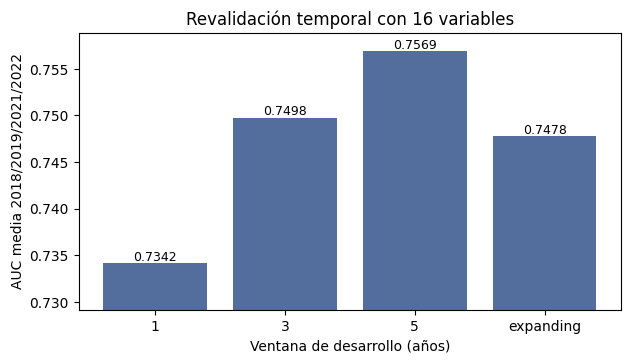

In [6]:
WINDOWS = (1, 3, 5, "expanding")
window_rows = []
for window in WINDOWS:
    for temporal in temporal_folds(frame, SELECTION_YEARS, window):
        encoded = encode_fold(frame, temporal)
        row, _, _, _ = evaluate_encoded(
            encoded, tuple(CANONICAL_ORDER), "xgboost", XGB_PARAMETERS
        )
        window_rows.append({"window": str(window), **row})

window_comparison = aggregate(pd.DataFrame(window_rows), ["window"]).sort_values(
    ["auc", "worst_fold_auc", "ks"], ascending=False
)
if window_comparison.iloc[0]["window"] != str(CHOSEN_WINDOW):
    raise AssertionError("la ventana revalidada no coincide con la especificación")
display(window_comparison)

fig, axis = plt.subplots(figsize=(7, 3.6))
ordered_windows = window_comparison.set_index("window").loc[
    [str(value) for value in WINDOWS]
]
axis.bar(ordered_windows.index, ordered_windows["auc"], color="#536d9c")
axis.set(
    title="Revalidación temporal con 16 variables",
    xlabel="Ventana de desarrollo (años)",
    ylabel="AUC media 2018/2019/2021/2022",
)
axis.set_ylim(ordered_windows["auc"].min() - 0.005, ordered_windows["auc"].max() + 0.002)
for index, value in enumerate(ordered_windows["auc"]):
    axis.text(index, value + 0.0003, f"{value:.4f}", ha="center", fontsize=9)
plt.show()

## 4. Máximo numérico y decisión de producto

Una criba amplia previa fijó XGBoost con 100 árboles, tasa 0,1, profundidad 2 y
ventana de cinco años. Aquí se vuelve a calcular la comparación que responde a la
decisión: los 16 prefijos y seis familias sobre exactamente los mismos años. La
ventana de diez años no era comparable porque el corte 2018 exigiría datos de 2003.

El máximo literal se registra, pero el producto conserva cinco variables cuando la
mejora de 16 es sólo marginal. Esta es una decisión explícita de parsimonia y uso,
no la afirmación falsa de que cinco alcance la mayor AUC.

In [7]:
def rank_models(table: pd.DataFrame) -> pd.DataFrame:
    if not table["folds"].eq(len(SELECTION_YEARS)).all():
        raise AssertionError("cada configuración debe contener los cuatro años")
    return table.sort_values(
        ["auc", "worst_fold_auc", "ks", "k"],
        ascending=[False, False, False, True],
    )


started = perf_counter()
k_rows = []
for temporal in temporal_folds(frame, SELECTION_YEARS, CHOSEN_WINDOW):
    encoded = encode_fold(frame, temporal)
    for k, contract in enumerate(paths, start=1):
        row, _, _, _ = evaluate_encoded(
            encoded, contract, "xgboost", XGB_PARAMETERS
        )
        k_rows.append(
            {
                "family": "xgboost",
                "config": "xgb_final",
                "parameters": json.dumps(XGB_PARAMETERS, sort_keys=True),
                "window": str(CHOSEN_WINDOW),
                "k": k,
                **row,
            }
        )
xgb_k_curve = rank_models(
    aggregate(
        pd.DataFrame(k_rows),
        ["family", "config", "parameters", "window", "k"],
    )
)
numerical_best_k = int(xgb_k_curve.iloc[0]["k"])
chosen_k = PRODUCT_K
chosen_window = CHOSEN_WINDOW
chosen_contract = paths[chosen_k - 1]
chosen_contract_name = f"ruta_forward_k{chosen_k}"

FINALIST_CONFIGURATIONS = {
    "logistic": {"C": 0.1},
    "tree": {"max_depth": 8, "min_samples_leaf": 200},
    "random_forest": {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 20,
        "max_features": "sqrt",
    },
    "adaboost": {"n_estimators": 100, "learning_rate": 0.5},
    "gradient_boosting": {
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 100,
    },
    "xgboost": XGB_PARAMETERS,
}
family_rows = []
for temporal in temporal_folds(frame, SELECTION_YEARS, chosen_window):
    encoded = encode_fold(frame, temporal)
    for family, parameters in FINALIST_CONFIGURATIONS.items():
        row, _, _, _ = evaluate_encoded(
            encoded, chosen_contract, family, parameters
        )
        family_rows.append(
            {
                "family": family,
                "config": family,
                "parameters": json.dumps(parameters, sort_keys=True),
                "window": str(chosen_window),
                "k": chosen_k,
                **row,
            }
        )
family_best = rank_models(
    aggregate(
        pd.DataFrame(family_rows),
        ["family", "config", "parameters", "window", "k"],
    )
)
chosen_model = family_best.iloc[0]
chosen_family = str(chosen_model["family"])
chosen_parameters = json.loads(chosen_model["parameters"])
print(f"Selección terminada en {(perf_counter() - started) / 60:.1f} minutos")
display(xgb_k_curve)
display(family_best)
display(
    Markdown(
        f"Máximo numérico: k={numerical_best_k}. "
        f"Contrato del producto: k={chosen_k} por parsimonia."
    )
)
display(chosen_model.to_frame("modelo_elegido"))

Selección terminada en 7.8 minutos


,family,config,parameters,window,k,folds,auc,pr_auc,ks,brier,log_loss,worst_fold_auc
15,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,16,4,0.756902,0.066962,0.396730,0.024046,0.127199,0.710510
14,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,15,4,0.755693,0.067375,0.394285,0.024052,0.127896,0.707918
4,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,5,4,0.755128,0.066109,0.388325,0.024025,0.126356,0.706411
5,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,6,4,0.755092,0.066161,0.388260,0.024026,0.126360,0.706007
6,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,7,4,0.755022,0.066159,0.386954,0.024023,0.126106,0.706313
13,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,14,4,0.753532,0.066864,0.390623,0.024023,0.126495,0.702884
7,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,8,4,0.752747,0.065915,0.388312,0.024015,0.125962,0.704055
12,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,13,4,0.752038,0.065663,0.389484,0.024033,0.126660,0.703816
8,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,9,4,0.751807,0.066179,0.387423,0.024016,0.126017,0.702836
10,xgboost,xgb_final,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,11,4,0.751779,0.065742,0.389696,0.024018,0.126203,0.701989


,family,config,parameters,window,k,folds,auc,pr_auc,ks,brier,log_loss,worst_fold_auc
5,xgboost,xgboost,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",5,5,4,0.755128,0.066109,0.388325,0.024025,0.126356,0.706411
1,gradient_boosting,gradient_boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",5,5,4,0.753217,0.065714,0.387668,0.024056,0.126969,0.703884
0,adaboost,adaboost,"{""learning_rate"": 0.5, ""n_estimators"": 100}",5,5,4,0.751369,0.062493,0.386146,0.063327,0.278712,0.704155
2,logistic,logistic,"{""C"": 0.1}",5,5,4,0.745813,0.064556,0.379125,0.023973,0.123951,0.695733
3,random_forest,random_forest,"{""max_depth"": 12, ""max_features"": ""sqrt"", ""min...",5,5,4,0.737513,0.063079,0.357867,0.023989,0.129175,0.690806
4,tree,tree,"{""max_depth"": 8, ""min_samples_leaf"": 200}",5,5,4,0.715737,0.057249,0.334203,0.024007,0.150175,0.663681


Máximo numérico: k=16. Contrato del producto: k=5 por parsimonia.

,modelo_elegido
family,xgboost
config,xgboost
parameters,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti..."
window,5
k,5
folds,4
auc,0.755128
pr_auc,0.066109
ks,0.388325
brier,0.024025


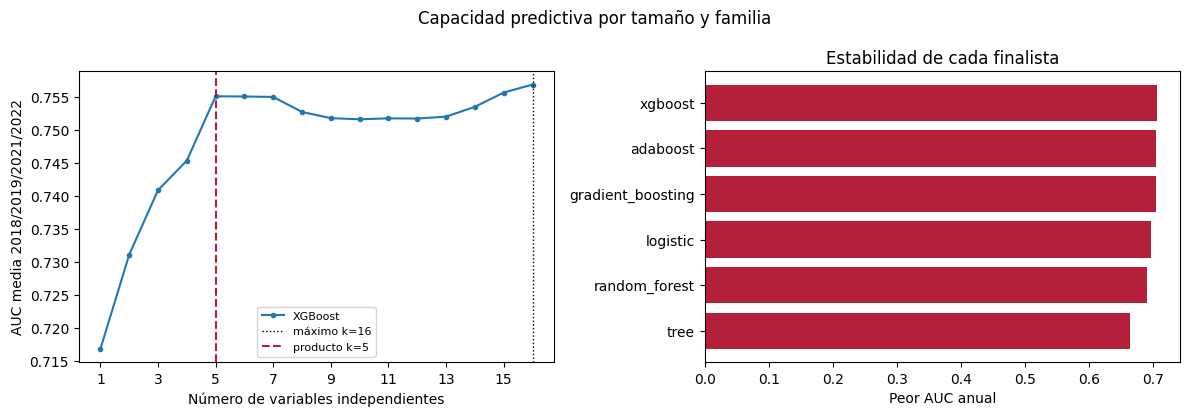

In [8]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
subset = xgb_k_curve.sort_values("k")
axes[0].plot(subset["k"], subset["auc"], marker="o", ms=3, label="XGBoost")
axes[0].axvline(
    numerical_best_k,
    color="black",
    ls=":",
    lw=1,
    label=f"máximo k={numerical_best_k}",
)
axes[0].axvline(
    chosen_k,
    color="#b41f3a",
    ls="--",
    lw=1.5,
    label=f"producto k={chosen_k}",
)
axes[0].set(
    xlabel="Número de variables independientes",
    ylabel="AUC media 2018/2019/2021/2022",
    xticks=range(1, len(CANDIDATES) + 1, 2),
)
axes[0].legend(fontsize=8)
ordered = family_best.sort_values("worst_fold_auc")
axes[1].barh(ordered["family"], ordered["worst_fold_auc"], color="#b41f3a")
axes[1].set(xlabel="Peor AUC anual", title="Estabilidad de cada finalista")
fig.suptitle("Capacidad predictiva por tamaño y familia")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fold_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Comprobación explícita de cinco, 16 y 18 entradas

Con familia, ventana e hiperparámetros ya congelados se comparan las cinco entradas
iniciales, las 16 variables independientes, las 18 columnas históricas y el prefijo
elegido. Todos usan exactamente los mismos años. Las dos columnas adicionales del
contrato histórico son sólo diagnósticas: una es constante y otra derivada.

In [9]:
CONTRACTS = {
    "cinco_variables": CURRENT_5,
    "independientes_16": paths[-1],
    "historico_18": (
        *paths[-1],
        *(feature for feature in LEGACY_18 if feature not in paths[-1]),
    ),
}
if chosen_contract not in CONTRACTS.values():
    CONTRACTS[chosen_contract_name] = chosen_contract

contract_rows = []
for temporal in temporal_folds(frame, SELECTION_YEARS, chosen_window):
    encoded = encode_fold(frame, temporal)
    for name, contract in CONTRACTS.items():
        row, _, _, _ = evaluate_encoded(
            encoded, contract, chosen_family, chosen_parameters
        )
        contract_rows.append(
            {"contract": name, "variables": len(contract), **row}
        )
contract_annual = pd.DataFrame(contract_rows)
contract_comparison = rank_models(
    aggregate(contract_annual, ["contract", "variables"]).rename(
        columns={"variables": "k"}
    )
).rename(columns={"k": "variables"})
five_auc = float(
    contract_comparison.loc[
        contract_comparison["contract"].eq("cinco_variables"), "auc"
    ].iloc[0]
)
contract_comparison["delta_auc_vs_5"] = contract_comparison["auc"] - five_auc
annual_auc = contract_annual.pivot(
    index="test_year", columns="contract", values="auc"
)
annual_auc["delta_16_vs_5"] = (
    annual_auc["independientes_16"] - annual_auc["cinco_variables"]
)
display(contract_comparison)
display(annual_auc)

,contract,variables,folds,auc,pr_auc,ks,brier,log_loss,worst_fold_auc,delta_auc_vs_5
2,independientes_16,16,4,0.756902,0.066962,0.396730,0.024046,0.127199,0.710510,0.001775
1,historico_18,18,4,0.756902,0.066962,0.396730,0.024046,0.127199,0.710510,0.001775
0,cinco_variables,5,4,0.755128,0.066109,0.388325,0.024025,0.126356,0.706411,0.000000


contract,cinco_variables,historico_18,independientes_16,delta_16_vs_5
test_year,,,,
2018,0.757967,0.758618,0.758618,0.000651
2019,0.706411,0.710510,0.710510,0.004099
2021,0.776334,0.773569,0.773569,-0.002765
2022,0.779799,0.784911,0.784911,0.005112


## 6. Alcance de la comparación

La regresión logística estandariza sólo sus variables numéricas; los árboles no
lo necesitan. Cada familia usa una configuración pequeña y visible, no una búsqueda
independiente de cientos de combinaciones. Ninguna usa pesos de clase, indicadores
de ausencia ni calibradores. PR-AUC, Brier y log-loss se informan como diagnóstico,
pero no deciden el ranking. Por ello el producto se presenta como score académico de
riesgo y no como una PD contractual calibrada. SVM se excluye porque el temario
advierte que no ofrece una interpretación probabilística nativa.

## 7. Estrés retrospectivo, estabilidad y prueba final reutilizada

Con contrato, ventana y configuración congelados se reconstruye cada corte anual.
2020 mide comportamiento bajo COVID como estrés retrospectivo; 2018, 2019, 2021
y 2022 son los años de selección; 2023 es la prueba final reutilizada.

In [10]:
ROLES = {
    2018: "selección",
    2019: "selección",
    2020: "estrés retrospectivo",
    2021: "selección",
    2022: "selección",
    2023: "prueba final reutilizada",
}


def evaluate_year(data: pd.DataFrame, year: int, keep_details: bool = False):
    temporal = temporal_folds(data, (year,), chosen_window)[0]
    encoded = encode_fold(data, temporal)
    row, probability, reference_probability, estimator = evaluate_encoded(
        encoded, chosen_contract, chosen_family, chosen_parameters
    )
    row["role"] = ROLES[year]
    if keep_details:
        return row, probability, reference_probability, estimator, encoded
    return row


annual_rows = [evaluate_year(frame, year) for year in range(2018, 2023)]
(
    final_row,
    final_probability,
    reference_probability,
    final_estimator,
    final_encoded,
) = evaluate_year(frame, FINAL_YEAR, keep_details=True)
annual = pd.DataFrame([*annual_rows, final_row])
display(
    annual[
        [
            "test_year",
            "role",
            "maturity_exclusions",
            "n",
            "events",
            "prevalence",
            "mean_score",
            *METRICS,
        ]
    ]
)

,test_year,role,maturity_exclusions,n,events,prevalence,mean_score,auc,pr_auc,ks,brier,log_loss
0,2018,selección,11,49761,1323,0.026587,0.008630,0.757967,0.079622,0.393083,0.025740,0.124067
1,2019,selección,9,49820,2205,0.044259,0.004517,0.706411,0.091315,0.311898,0.043570,0.237949
2,2020,estrés retrospectivo,16,49874,773,0.015499,0.001821,0.746118,0.049297,0.383398,0.015366,0.094257
3,2021,selección,10,49878,430,0.008621,0.001837,0.776334,0.029611,0.417582,0.008549,0.051930
4,2022,selección,11,49877,933,0.018706,0.006280,0.779799,0.063889,0.430735,0.018243,0.091478
5,2023,prueba final reutilizada,9,49815,853,0.017123,0.009184,0.790355,0.060381,0.453622,0.016581,0.079926


In [11]:
cutoffs = np.quantile(reference_probability, [0.5, 0.9])
bands = pd.cut(
    final_probability,
    bins=[-np.inf, cutoffs[0], cutoffs[1], np.inf],
    labels=["bajo", "medio", "alto"],
    right=False,
)
band_table = (
    pd.DataFrame(
        {
            "band": bands,
            "outcome": final_encoded.y_test,
            "probability": final_probability,
        }
    )
    .groupby("band", observed=True)
    .agg(
        n=("outcome", "size"),
        observed=("outcome", "mean"),
        mean_score=("probability", "mean"),
    )
    .reset_index()
)
display(band_table)


def source_importance(estimator: object, features: tuple[str, ...]) -> pd.Series:
    transformer = estimator.steps[0][1]
    classifier = estimator.steps[-1][1]
    values = (
        classifier.feature_importances_
        if hasattr(classifier, "feature_importances_")
        else np.abs(classifier.coef_[0])
    )
    numeric = [feature for feature in features if feature in NUMERIC]
    categorical = [feature for feature in features if feature in CATEGORICAL]
    if not categorical:
        importance = dict(zip(features, map(float, values)))
    else:
        numeric_slice = transformer.output_indices_["numeric"]
        importance = dict(zip(numeric, map(float, values[numeric_slice])))
        encoder = transformer.named_transformers_["categorical"].named_steps[
            "onehotencoder"
        ]
        offset = transformer.output_indices_["categorical"].start
        for feature, categories in zip(categorical, encoder.categories_):
            width = len(categories)
            importance[feature] = float(values[offset : offset + width].sum())
            offset += width
    result = pd.Series(importance).sort_values(ascending=False)
    return result / result.sum()


importance = source_importance(final_estimator, chosen_contract)
display(importance.rename("importancia_relativa").to_frame())

,band,n,observed,mean_score
0,bajo,18281,0.002407,0.001953
1,medio,23718,0.016359,0.007849
2,alto,7816,0.053864,0.030145


,importancia_relativa
origination_fico,0.464112
number_of_borrowers,0.214165
original_cltv,0.137528
original_dti,0.094107
original_interest_rate,0.090088


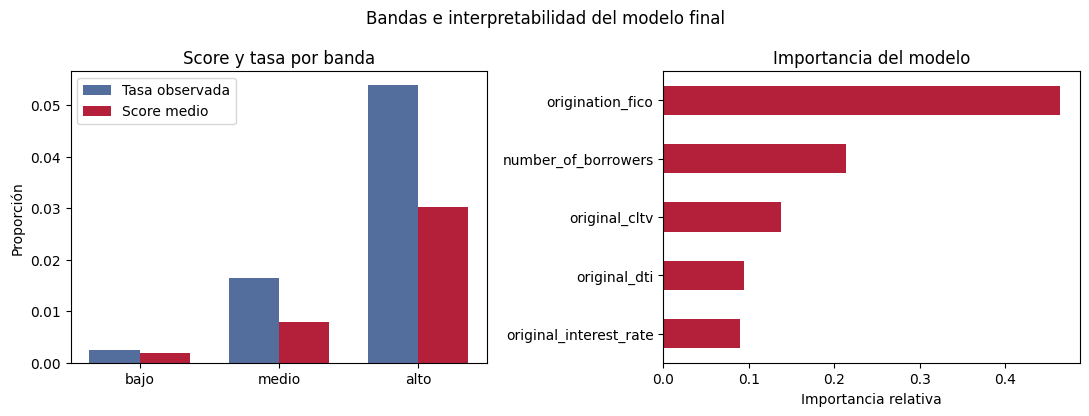

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
positions = np.arange(len(band_table))
width = 0.36
axes[0].bar(
    positions - width / 2,
    band_table["observed"],
    width,
    color="#536d9c",
    label="Tasa observada",
)
axes[0].bar(
    positions + width / 2,
    band_table["mean_score"],
    width,
    color="#b41f3a",
    label="Score medio",
)
axes[0].set_xticks(positions, band_table["band"])
axes[0].set(title="Score y tasa por banda", ylabel="Proporción")
axes[0].legend()
importance.sort_values().plot.barh(ax=axes[1], color="#b41f3a")
axes[1].set(title="Importancia del modelo", xlabel="Importancia relativa")
fig.suptitle("Bandas e interpretabilidad del modelo final")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "bands_interpretability.png", dpi=180, bbox_inches="tight")
plt.show()

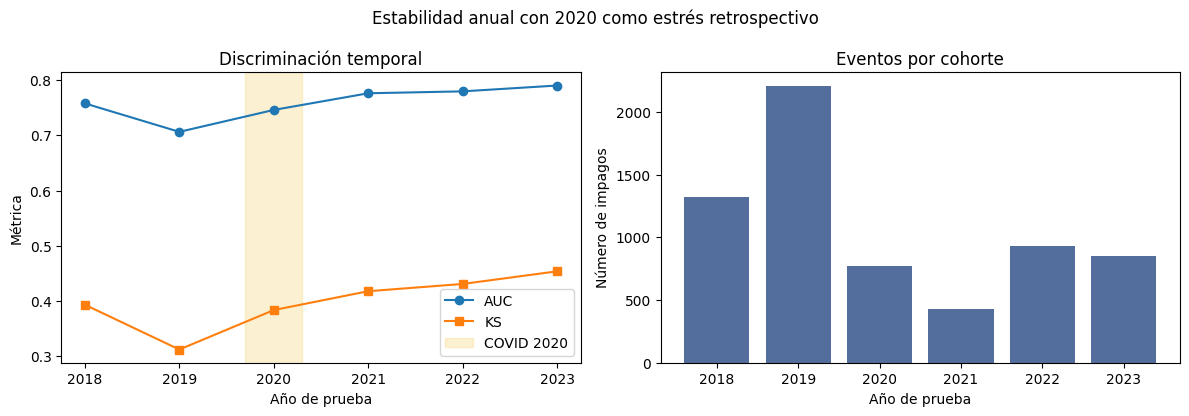

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(annual["test_year"], annual["auc"], "o-", label="AUC")
axes[0].plot(annual["test_year"], annual["ks"], "s-", label="KS")
axes[0].axvspan(2019.7, 2020.3, color="#f2c94c", alpha=0.25, label="COVID 2020")
axes[0].set(
    xticks=annual["test_year"],
    xlabel="Año de prueba",
    ylabel="Métrica",
    title="Discriminación temporal",
)
axes[0].legend()
axes[1].bar(annual["test_year"], annual["events"], color="#536d9c")
axes[1].set(
    xticks=annual["test_year"],
    xlabel="Año de prueba",
    ylabel="Número de impagos",
    title="Eventos por cohorte",
)
fig.suptitle("Estabilidad anual con 2020 como estrés retrospectivo")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "temporal_performance.png", dpi=180, bbox_inches="tight")
plt.show()

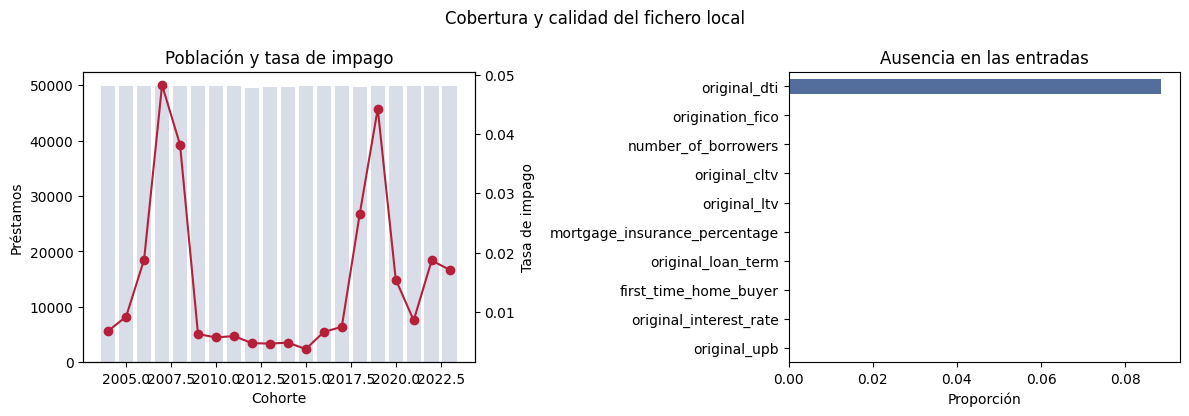

In [14]:
annual_quality = (
    frame.groupby(YEAR)
    .agg(
        filas=(TARGET, "size"),
        tasa_impago=(TARGET, "mean"),
    )
    .reset_index()
)
missing = frame.attrs["missingness"].sort_values(ascending=False).head(10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
left = axes[0]
right = left.twinx()
left.bar(
    annual_quality[YEAR], annual_quality["filas"], color="#d9dde7", label="Préstamos"
)
right.plot(
    annual_quality[YEAR],
    annual_quality["tasa_impago"],
    color="#b41f3a",
    marker="o",
    label="Tasa",
)
left.set(xlabel="Cohorte", ylabel="Préstamos", title="Población y tasa de impago")
right.set_ylabel("Tasa de impago")
missing.sort_values().plot.barh(ax=axes[1], color="#536d9c")
axes[1].set(title="Ausencia en las entradas", xlabel="Proporción")
fig.suptitle("Cobertura y calidad del fichero local")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_population_quality.png", dpi=180, bbox_inches="tight")
plt.show()

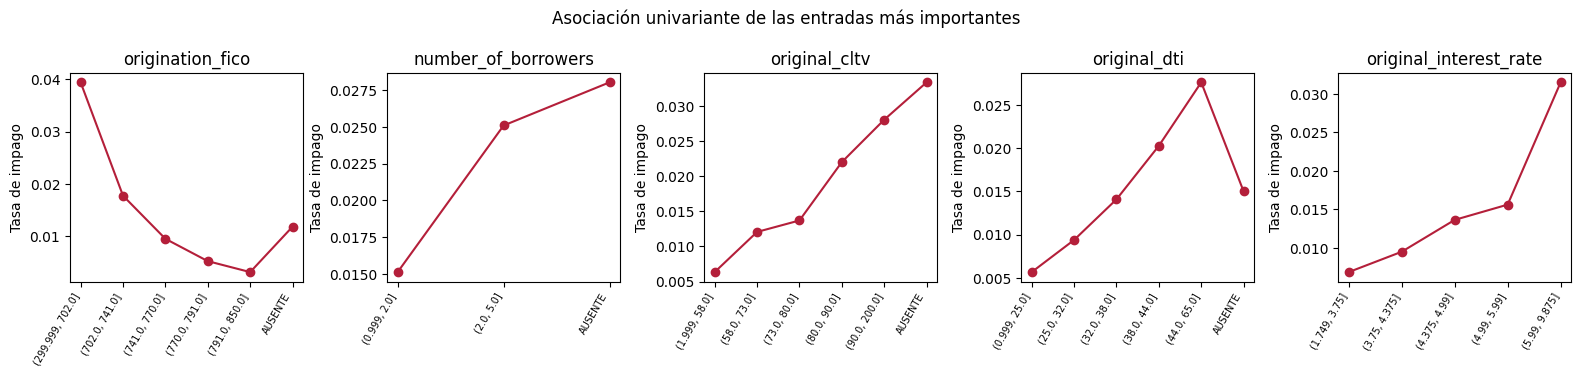

In [15]:
def empirical_gradient(data: pd.DataFrame, feature: str) -> pd.DataFrame:
    sample = data[[feature, TARGET]].copy()
    if feature in NUMERIC:
        sample["group"] = (
            pd.qcut(sample[feature], 5, duplicates="drop")
            .astype("string")
            .fillna("AUSENTE")
        )
    else:
        common = sample[feature].value_counts().head(5).index
        sample["group"] = sample[feature].where(sample[feature].isin(common), "OTRAS")
    return (
        sample.groupby("group", observed=True)[TARGET]
        .mean()
        .rename("rate")
        .reset_index()
    )


top_features = list(importance.head(min(5, len(importance))).index)
fig, axes = plt.subplots(
    1, len(top_features), figsize=(3.2 * len(top_features), 3.8), squeeze=False
)
for axis, feature in zip(axes[0], top_features):
    gradient = empirical_gradient(frame, feature)
    axis.plot(range(len(gradient)), gradient["rate"], "o-", color="#b41f3a")
    axis.set_xticks(
        range(len(gradient)),
        [str(value) for value in gradient["group"]],
        rotation=60,
        ha="right",
        fontsize=7,
    )
    axis.set(title=feature, ylabel="Tasa de impago")
fig.suptitle("Asociación univariante de las entradas más importantes")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_feature_gradients.png", dpi=180, bbox_inches="tight")
plt.show()

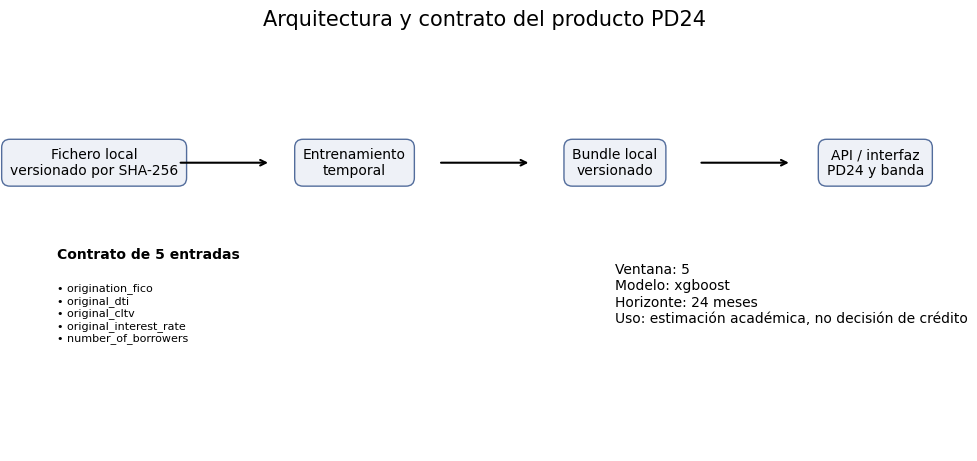

In [16]:
fig, axis = plt.subplots(figsize=(12, 5.2))
axis.axis("off")
steps = [
    "Fichero local\nversionado por SHA-256",
    "Entrenamiento\ntemporal",
    "Bundle local\nversionado",
    "API / interfaz\nPD24 y banda",
]
x_positions = np.linspace(0.08, 0.92, len(steps))
for index, (x, text) in enumerate(zip(x_positions, steps)):
    axis.text(
        x,
        0.72,
        text,
        ha="center",
        va="center",
        transform=axis.transAxes,
        bbox={
            "boxstyle": "round,pad=0.6",
            "facecolor": "#eef1f7",
            "edgecolor": "#536d9c",
        },
    )
    if index < len(steps) - 1:
        axis.annotate(
            "",
            xy=(x_positions[index + 1] - 0.09, 0.72),
            xytext=(x + 0.09, 0.72),
            xycoords=axis.transAxes,
            arrowprops={"arrowstyle": "->", "lw": 1.5},
        )
axis.text(
    0.04,
    0.48,
    f"Contrato de {chosen_k} entradas",
    weight="bold",
    transform=axis.transAxes,
)
feature_columns = np.array_split(chosen_contract, 2 if chosen_k > 8 else 1)
for column, features in enumerate(feature_columns):
    axis.text(
        0.04 + 0.27 * column,
        0.42,
        "\n".join(f"• {feature}" for feature in features),
        va="top",
        transform=axis.transAxes,
        fontsize=8,
    )
axis.text(
    0.64,
    0.47,
    f"Ventana: {chosen_window}\nModelo: {chosen_family}\nHorizonte: 24 meses\nUso: estimación académica, no decisión de crédito",
    va="top",
    transform=axis.transAxes,
    fontsize=10,
)
axis.set_title("Arquitectura y contrato del producto PD24", fontsize=15, pad=18)
fig.savefig(FIGURE_DIR / "product_api_contract.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Especificación reproducible obtenida

El producto congela exactamente el estimador evaluado en 2023: se ajusta con los
años de desarrollo de ese corte y calcula las bandas con sus dos años de referencia.
No se hace un reajuste posterior que carecería de una cohorte madura independiente.

In [17]:
product_specification = {
    "data_sha256": EXPECTED_SHA256,
    "candidate_independent_variables": len(CANDIDATES),
    "selected_k": chosen_k,
    "selected_features": list(chosen_contract),
    "selected_window": chosen_window,
    "family": chosen_family,
    "parameters": chosen_parameters,
    "evaluated_backtest_band_cutoffs": [float(value) for value in cutoffs],
    "served_model_evaluated_2023": {
        "development_years": list(final_encoded.development_years),
        "band_reference_years": [FINAL_YEAR - 5, FINAL_YEAR - 4],
        "test_year": FINAL_YEAR,
    },
    "final_2023": {
        name: final_row[name]
        for name in (
            "n",
            "events",
            "prevalence",
            "mean_score",
            *METRICS,
        )
    },
}
print(json.dumps(product_specification, indent=2, ensure_ascii=False))

five_row = contract_comparison.loc[
    contract_comparison["contract"].eq("cinco_variables")
].iloc[0]
independent_row = contract_comparison.loc[
    contract_comparison["contract"].eq("independientes_16")
].iloc[0]
legacy_row = contract_comparison.loc[
    contract_comparison["contract"].eq("historico_18")
].iloc[0]
runner_up = rank_models(family_best).iloc[1]
wins_16_vs_5 = int(annual_auc["delta_16_vs_5"].gt(0).sum())
display(
    Markdown(
        f"""
### Conclusión limitada a este experimento

- La criba previa congeló configuración y ventana. La curva reproducida alcanza su máximo literal en `k={numerical_best_k}`, pero el producto conserva `k={chosen_k}` porque la mejora no compensa once entradas adicionales. Con ese contrato, el mejor finalista usa `{chosen_family}`, ventana `{chosen_window}` y `{chosen_parameters}`, con AUC media `{chosen_model["auc"]:.4f}`.
- El segundo finalista fue `{runner_up["family"]}` con AUC `{runner_up["auc"]:.4f}`.
- Con el ajuste ganador, cinco entradas obtienen AUC `{five_row["auc"]:.4f}`, 16 entradas `{independent_row["auc"]:.4f}` y las 18 históricas `{legacy_row["auc"]:.4f}`. Las 16 superan a cinco en `{wins_16_vs_5}` de los cuatro años de selección; la diferencia media es `{independent_row["auc"] - five_row["auc"]:+.4f}`.
- Las 18 entradas no son un contrato elegible: incluyen una constante y una variable derivada, y se conservan sólo como diagnóstico.
- 2020 es estrés retrospectivo y 2023 una prueba final reutilizada, no un holdout virgen.
- En 2023 el score medio fue `{final_row["mean_score"]:.4f}` frente a una tasa observada
  de `{final_row["prevalence"]:.4f}`. La salida se interpreta como estimación académica,
  no como probabilidad contractual validada.
- El bundle conserva exactamente el modelo evaluado en 2023; no incorpora un reajuste posterior sin validación independiente.
- La conclusión distingue máximo estadístico y decisión de producto. No demuestra un
  óptimo conjunto ni universal.
"""
    )
)

{
  "data_sha256": "316dc7b4c16878d9ca62694626263e3a9276512809000d003f456fffe0740589",
  "candidate_independent_variables": 16,
  "selected_k": 5,
  "selected_features": [
    "origination_fico",
    "original_dti",
    "original_cltv",
    "original_interest_rate",
    "number_of_borrowers"
  ],
  "selected_window": 5,
  "family": "xgboost",
  "parameters": {
    "learning_rate": 0.1,
    "max_depth": 2,
    "n_estimators": 100
  },
  "evaluated_backtest_band_cutoffs": [
    0.0033427400048822165,
    0.016638795286417023
  ],
  "served_model_evaluated_2023": {
    "development_years": [
      2013,
      2014,
      2015,
      2016,
      2017
    ],
    "band_reference_years": [
      2018,
      2019
    ],
    "test_year": 2023
  },
  "final_2023": {
    "n": 49815,
    "events": 853,
    "prevalence": 0.01712335641874937,
    "mean_score": 0.009183591231703758,
    "auc": 0.7903550031598541,
    "pr_auc": 0.06038141360265419,
    "ks": 0.45362216687602264,
    "brier": 0.0165813


### Conclusión limitada a este experimento

- La criba previa congeló configuración y ventana. La curva reproducida alcanza su máximo literal en `k=16`, pero el producto conserva `k=5` porque la mejora no compensa once entradas adicionales. Con ese contrato, el mejor finalista usa `xgboost`, ventana `5` y `{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}`, con AUC media `0.7551`.
- El segundo finalista fue `gradient_boosting` con AUC `0.7532`.
- Con el ajuste ganador, cinco entradas obtienen AUC `0.7551`, 16 entradas `0.7569` y las 18 históricas `0.7569`. Las 16 superan a cinco en `3` de los cuatro años de selección; la diferencia media es `+0.0018`.
- Las 18 entradas no son un contrato elegible: incluyen una constante y una variable derivada, y se conservan sólo como diagnóstico.
- 2020 es estrés retrospectivo y 2023 una prueba final reutilizada, no un holdout virgen.
- En 2023 el score medio fue `0.0092` frente a una tasa observada
  de `0.0171`. La salida se interpreta como estimación académica,
  no como probabilidad contractual validada.
- El bundle conserva exactamente el modelo evaluado en 2023; no incorpora un reajuste posterior sin validación independiente.
- La conclusión distingue máximo estadístico y decisión de producto. No demuestra un
  óptimo conjunto ni universal.


## 9. Demostración ejecutable del producto

Esta sección usa la implementación real de `src/` como única fuente de verdad.
Entrena y guarda el bundle, lo vuelve a cargar, puntúa un préstamo, comprueba los
endpoints sin iniciar un servidor persistente, construye la interfaz Gradio y
ejecuta la suite automática. Así **Run All** termina de forma autónoma.

La última celda permite abrir la interfaz dentro de Jupyter cambiando una sola
variable. Se deja desactivada por defecto para que una ejecución completa no quede
bloqueada esperando al servidor web.

In [18]:
import subprocess

from scripts.serve_demo import create_demo
from src.api import create_app
from src.product import load_bundle, save_bundle, score_product, train_product

MODEL_PATH = PROJECT_ROOT / "models" / "pd24-model.joblib"
product_bundle = train_product(DATA_PATH)
save_bundle(product_bundle, MODEL_PATH)
loaded_bundle = load_bundle(MODEL_PATH)

if loaded_bundle["features"] != list(chosen_contract):
    raise AssertionError("el contrato del bundle no coincide con la selección")
if loaded_bundle["family"] != chosen_family:
    raise AssertionError("la familia del bundle no coincide con la selección")
if not np.allclose(loaded_bundle["risk_band_cutoffs"], cutoffs, rtol=0, atol=1e-15):
    raise AssertionError("los cortes del bundle no coinciden con la evaluación")

sample_loan = {
    "origination_fico": 700,
    "original_dti": 30,
    "original_cltv": 80,
    "original_interest_rate": 4.5,
    "number_of_borrowers": 2,
}
sample_score, sample_band = score_product(loaded_bundle, sample_loan)

client = create_app(MODEL_PATH).test_client()
health_response = client.get("/health")
prediction_response = client.post("/predict", json=sample_loan)
invalid_response = client.post("/predict", json={**sample_loan, "extra": 1})
if (health_response.status_code, prediction_response.status_code, invalid_response.status_code) != (
    200,
    200,
    400,
):
    raise AssertionError("la validación HTTP no produjo 200/200/400")

demo = create_demo(str(MODEL_PATH))
test_run = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-q"],
    text=True,
    capture_output=True,
    check=False,
    cwd=PROJECT_ROOT,
)
if test_run.returncode:
    raise RuntimeError(test_run.stdout + test_run.stderr)

display(
    pd.DataFrame(
        [
            {"comprobación": "bundle entrenado y recargado", "resultado": loaded_bundle["model_version"]},
            {"comprobación": "score directo", "resultado": f"{sample_score:.12f}"},
            {"comprobación": "banda directa", "resultado": sample_band},
            {"comprobación": "GET /health", "resultado": health_response.status_code},
            {"comprobación": "POST /predict", "resultado": prediction_response.status_code},
            {"comprobación": "entrada adicional", "resultado": invalid_response.status_code},
            {"comprobación": "interfaz Gradio", "resultado": "construida"},
            {"comprobación": "tests", "resultado": "correctos"},
        ]
    )
)
display(pd.json_normalize(prediction_response.get_json()))

,comprobación,resultado
0,bundle entrenado y recargado,pd24-xgboost-5v-7
1,score directo,0.003416217165
2,banda directa,medium
3,GET /health,200
4,POST /predict,200
5,entrada adicional,400
6,interfaz Gradio,construida
7,tests,correctos


,horizon_months,model_version,risk_band,risk_score,warning
0,24,pd24-xgboost-5v-7,medium,0.003416,Academic risk estimate; not a credit decision.


In [19]:
LAUNCH_WEB_DEMO = False
if LAUNCH_WEB_DEMO:
    demo.launch(
        server_name="127.0.0.1",
        server_port=7860,
        share=False,
        inline=True,
        prevent_thread_lock=True,
    )
else:
    display(
        Markdown(
            "La interfaz está construida. Cambie `LAUNCH_WEB_DEMO` a `True` "
            "y ejecute sólo esta celda para abrirla dentro de Jupyter."
        )
    )

La interfaz está construida. Cambie `LAUNCH_WEB_DEMO` a `True` y ejecute sólo esta celda para abrirla dentro de Jupyter.

## 10. Límites

La selección es *greedy* y temporal, no exhaustiva. Las métricas no autorizan aprobar
o denegar préstamos, ni estiman EAD, LGD o pérdida esperada. Una validación realmente
ciega exigiría una cohorte posterior completa y madura que no
hubiese sido observada durante el desarrollo. El bundle conserva el modelo evaluado
en 2023 y sólo debería reajustarse cuando exista una cohorte posterior independiente.